# ?? Titanic Disaster: Data Preprocessing & Exploratory Data Analysis (EDA)

## Project Overview
This notebook presents an end-to-end data preprocessing, data cleaning, and exploratory data analysis (EDA) pipeline conducted on the canonical **Titanic: Machine Learning from Disaster** dataset (publicly hosted on Kaggle and UCI repository mirrors).

### Key Objectives:
1. **Data Ingestion & Integrity Auditing**: Assess raw schemas, missingness mechanisms, and duplicate records.
2. **Rigorous Data Cleaning**:
   - Resolve missing values (`Embarked`, `Age`, `Cabin`) using statistically justified domain imputations.
   - Detect and evaluate full-row and partial duplicates.
3. **Outlier Detection & Treatment**:
   - Implement Tukey's Interquartile Range (IQR) method:
     $$\text{IQR} = Q_3 - Q_1$$
     $$\text{Lower Fence} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Upper Fence} = Q_3 + 1.5 \times \text{IQR}$$
   - Apply 99th-percentile Winsorization and log-transformations to normalize high-variance economic variables (`Fare`).
4. **Domain Feature Engineering**: Synthesize predictive features (`Title`, `FamilySize`, `IsAlone`, `Deck`, `AgeGroup`).
5. **Exploratory Data Analysis**:
   - Comprehensive summary statistics (central tendency, dispersion, skewness, kurtosis).
   - High-impact univariate, bivariate, and multivariate visualizations.
6. **Executive Insights**: Provide quantitative and behavioral takeaways for downstream predictive modeling.

In [1]:
import os
import warnings
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Visual style setup
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.titlesize': 15,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.autolayout': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

print("Core libraries imported and graphics environment configured successfully.")

Core libraries imported and graphics environment configured successfully.


## 1. Data Ingestion & Initial Inspection
We load the raw Titanic dataset directly from the public repository and examine its structural dimensions, data types, and initial records.

In [2]:
RAW_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
raw_data_path = os.path.join("data", "raw", "titanic_raw.csv")

if not os.path.exists(raw_data_path):
    os.makedirs(os.path.dirname(raw_data_path), exist_ok=True)
    urllib.request.urlretrieve(RAW_URL, raw_data_path)

df_raw = pd.read_csv(raw_data_path)
print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")
display(df_raw.head())

Dataset Dimensions: 891 rows, 12 columns



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("--- Data Schema & Memory Footprint ---")
df_raw.info()

--- Data Schema & Memory Footprint ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
print("--- Initial Five-Number Summary & Descriptive Statistics ---")
display(df_raw.describe(include='all').T)

--- Initial Five-Number Summary & Descriptive Statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 2. Data Cleaning: Missing Values & Duplicates

### 2.1 Duplicate Record Diagnosis
We verify whether identical passenger entries or duplicate primary keys (`PassengerId`) exist.

In [5]:
exact_duplicates = df_raw.duplicated().sum()
id_duplicates = df_raw.duplicated(subset=['PassengerId']).sum()

print(f"Total exact row duplicates: {exact_duplicates}")
print(f"Total PassengerId primary key duplicates: {id_duplicates}")

Total exact row duplicates: 0
Total PassengerId primary key duplicates: 0


### 2.2 Missing Value Profiling
We compute the magnitude and proportion of missingness across all features to determine appropriate imputation strategies:
- `Embarked`: 2 missing values (<0.25%) $\rightarrow$ Imputed with the statistical mode (`'S'`).
- `Age`: 177 missing values (19.87%) $\rightarrow$ Rather than an oversimplified global median, we engineer a `Title` feature (`Mr`, `Mrs`, `Miss`, `Master`, etc.) and impute grouped medians conditioned on `Title` and `Pclass`.
- `Cabin`: 687 missing values (77.10%) $\rightarrow$ Missing Not At Random (MNAR). We retain the informational value by creating a binary indicator `Has_Cabin` and extracting the `Deck` level.

In [6]:
missing_counts = df_raw.isnull().sum()
missing_pct = (missing_counts / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Percentage (%)': missing_pct.round(2)})
display(missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False))

,Missing_Count,Percentage (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [7]:
df_clean = df_raw.copy()

# 1. Impute Embarked with Mode
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)
print(f"Imputed 'Embarked' missing entries with mode: '{embarked_mode}'")

# 2. Extract Title from Name
def extract_title(name):
    if not isinstance(name, str):
        return 'Unknown'
    title = name.split(',')[1].split('.')[0].strip()
    title_mapping = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss', 'Lady': 'Rare',
        'Sir': 'Rare', 'Capt': 'Rare', 'Countess': 'Rare', 'Jonkheer': 'Rare',
        'Don': 'Rare', 'Dona': 'Rare'
    }
    return title_mapping.get(title, 'Rare')

df_clean['Title'] = df_clean['Name'].apply(extract_title)
print(f"Extracted Titles breakdown:\n{df_clean['Title'].value_counts()}\n")

# 3. Impute Age using Grouped Median (Title x Pclass)
df_clean['Age_Original'] = df_clean['Age'].copy()
grouped_medians = df_clean.groupby(['Title', 'Pclass'])['Age'].transform('median')
df_clean['Age'] = df_clean['Age'].fillna(grouped_medians).fillna(df_clean['Age'].median())
print("Successfully performed grouped median imputation on 'Age'.")

# 4. Decompose Cabin into Has_Cabin flag and Deck letter
df_clean['Has_Cabin'] = df_clean['Cabin'].notnull().astype(int)
df_clean['Deck'] = df_clean['Cabin'].apply(lambda c: str(c)[0] if pd.notnull(c) else 'Unknown')
print(f"Cabin transformed into 'Has_Cabin' (Presence: {df_clean['Has_Cabin'].mean()*100:.1f}%) and 'Deck'.")

Imputed 'Embarked' missing entries with mode: 'S'
Extracted Titles breakdown:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Successfully performed grouped median imputation on 'Age'.
Cabin transformed into 'Has_Cabin' (Presence: 22.9%) and 'Deck'.


## 3. Outlier Detection and Treatment
We analyze the numerical features `Fare` and `Age` using Tukey's Interquartile Range (IQR) method:
$$\text{IQR} = Q_3 - Q_1$$
Observations falling outside $[Q_1 - 1.5\times\text{IQR},\; Q_3 + 1.5\times\text{IQR}]$ are evaluated.

In [8]:
def detect_iqr_outliers(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    mask = (series < lower_bound) | (series > upper_bound)
    return lower_bound, upper_bound, mask, mask.sum()

fare_lb, fare_ub, fare_mask, fare_count = detect_iqr_outliers(df_clean['Fare'])
age_lb, age_ub, age_mask, age_count = detect_iqr_outliers(df_clean['Age'])

print(f"Fare IQR Bounds: [{fare_lb:.2f}, {fare_ub:.2f}] | Outlier Count: {fare_count} ({fare_count/len(df_clean)*100:.2f}%)")
print(f"Age IQR Bounds: [{age_lb:.2f}, {age_ub:.2f}] | Outlier Count: {age_count} ({age_count/len(df_clean)*100:.2f}%)")

Fare IQR Bounds: [-26.72, 65.63] | Outlier Count: 116 (13.02%)
Age IQR Bounds: [-2.62, 60.38] | Outlier Count: 22 (2.47%)


### Treatment Strategy:
- **`Fare`**: High positive skewness ($>4.7$) driven by luxury suites ($Fare > \$500$). We apply **99th-percentile Winsorization** (`Fare_Capped`) to curb extreme leverage points while retaining ordinal price disparity, and engineer a **log-transformed feature** `Fare_Log = log1p(Fare_Capped)` for distributional normality.
- **`Age`**: Upper outliers ($Age > 60$) represent authentic elderly passengers whose survival rates represent crucial historical evidence; these are preserved without truncation.

In [9]:
df_clean['Fare_Original'] = df_clean['Fare'].copy()
fare_p99 = df_clean['Fare'].quantile(0.99)
df_clean['Fare_Capped'] = np.clip(df_clean['Fare'], a_min=0.0, a_max=fare_p99)
df_clean['Fare_Log'] = np.log1p(df_clean['Fare_Capped'])

print(f"Fare 99th Percentile Cap: {fare_p99:.2f}")
print(f"Original Fare Skewness: {df_clean['Fare_Original'].skew():.2f}")
print(f"Capped Fare Skewness: {df_clean['Fare_Capped'].skew():.2f}")
print(f"Log1p Fare Skewness: {df_clean['Fare_Log'].skew():.2f}")

Fare 99th Percentile Cap: 249.01
Original Fare Skewness: 4.79
Capped Fare Skewness: 3.11
Log1p Fare Skewness: 0.34


## 4. Domain Feature Engineering
We synthesize behavioral and sociological predictors:
1. `FamilySize`: Total traveling companions including the passenger ($SibSp + Parch + 1$).
2. `IsAlone`: Binary flag ($1$ if traveling solo, $0$ otherwise).
3. `AgeGroup`: Categorical bins (*Child [0-12]*, *Adolescent [12-18]*, *Young Adult [18-35]*, *Middle-Aged [35-60]*, *Senior [60+]*).

In [10]:
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

age_bins = [0, 12, 18, 35, 60, 120]
age_labels = ['Child', 'Adolescent', 'Young Adult', 'Middle-Aged', 'Senior']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=age_bins, labels=age_labels, right=True)

display(df_clean[['PassengerId', 'Sex', 'Age', 'AgeGroup', 'FamilySize', 'IsAlone', 'Fare_Capped', 'Fare_Log', 'Has_Cabin']].head())

,PassengerId,Sex,Age,AgeGroup,FamilySize,IsAlone,Fare_Capped,Fare_Log,Has_Cabin
0,1,male,22.0,Young Adult,2,0,7.2500,2.110213,0
1,2,female,38.0,Middle-Aged,2,0,71.2833,4.280593,1
2,3,female,26.0,Young Adult,1,1,7.9250,2.188856,0
3,4,female,35.0,Young Adult,2,0,53.1000,3.990834,1
4,5,male,35.0,Young Adult,1,1,8.0500,2.202765,0


## 5. Exploratory Data Analysis (EDA) & Summary Statistics

### 5.1 Summary Statistics Table

In [11]:
num_cols = ["Age", "Fare", "Fare_Capped", "Fare_Log", "SibSp", "Parch", "FamilySize"]
stats_rows = []
for c in num_cols:
    s = df_clean[c]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    stats_rows.append({
        "Feature": c,
        "Mean": s.mean(),
        "Std": s.std(),
        "Min": s.min(),
        "25% (Q1)": q1,
        "Median (50%)": s.median(),
        "75% (Q3)": q3,
        "Max": s.max(),
        "IQR": q3 - q1,
        "Skewness": s.skew(),
        "Kurtosis": s.kurt()
    })

summary_stats_df = pd.DataFrame(stats_rows).round(2)
display(summary_stats_df)

,Feature,Mean,Std,Min,25% (Q1),Median (50%),75% (Q3),Max,IQR,Skewness,Kurtosis
0,Age,29.14,13.49,0.42,21.00,26.00,36.75,80.00,15.75,0.47,0.59
1,Fare,32.20,49.69,0.00,7.91,14.45,31.00,512.33,23.09,4.79,33.40
2,Fare_Capped,31.22,42.52,0.00,7.91,14.45,31.00,249.01,23.09,3.11,11.03
3,Fare_Log,2.96,0.96,0.00,2.19,2.74,3.47,5.52,1.28,0.34,0.80
4,SibSp,0.52,1.10,0.00,0.00,0.00,1.00,8.00,1.00,3.70,17.88
5,Parch,0.38,0.81,0.00,0.00,0.00,0.00,6.00,0.00,2.75,9.78
6,FamilySize,1.90,1.61,1.00,1.00,1.00,2.00,11.00,1.00,2.73,9.16


### 5.2 Outlier & Distribution Treatment Visualization

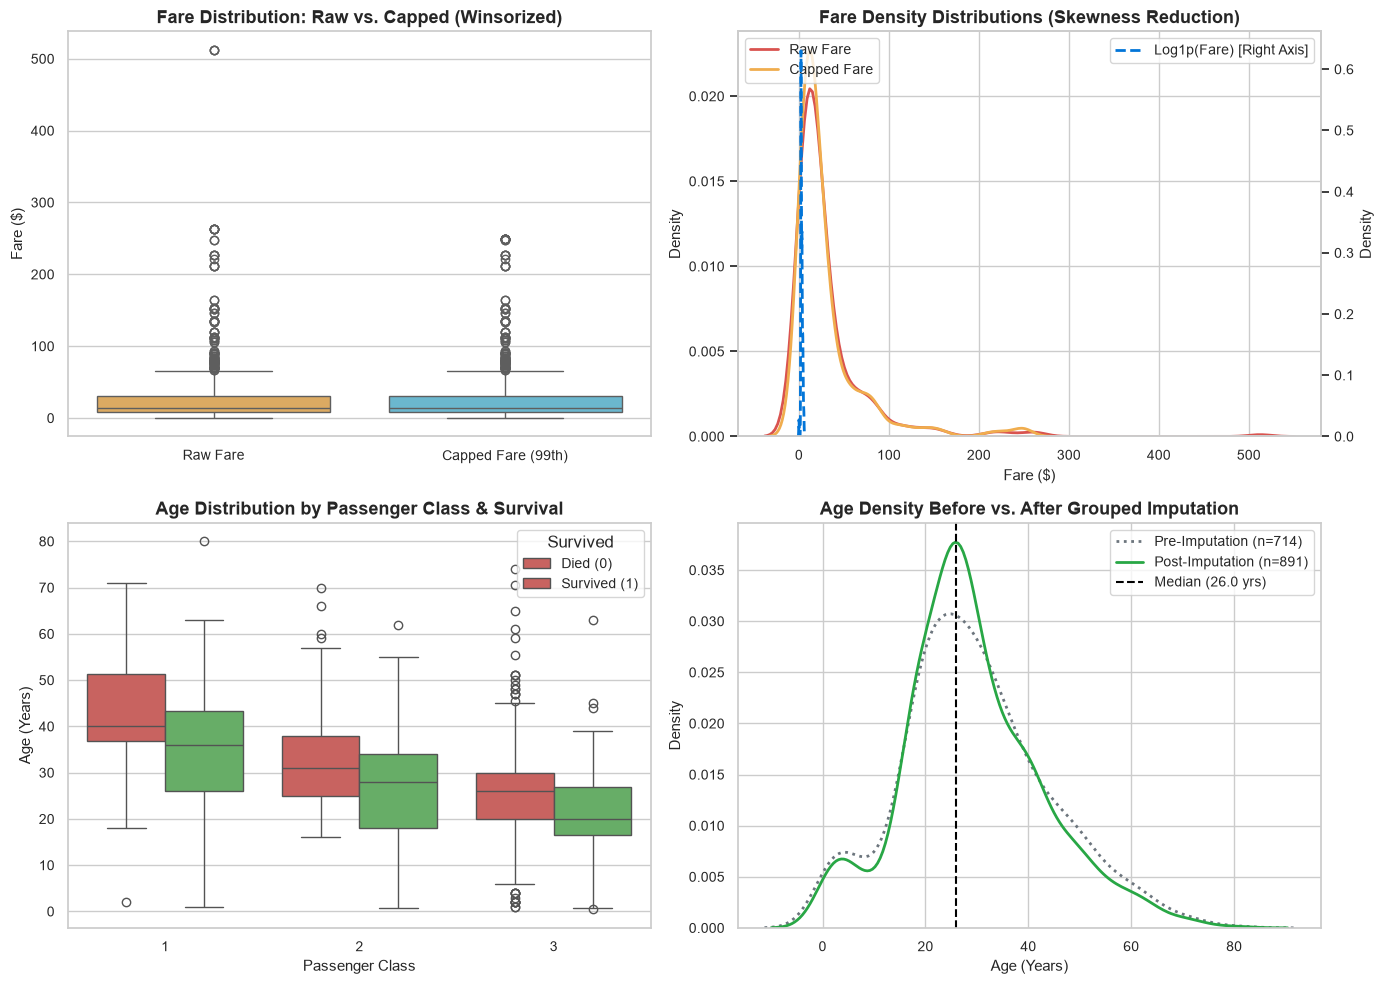

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fare Boxplots
fare_comp = pd.DataFrame({"Raw Fare": df_clean["Fare_Original"], "Capped Fare (99th)": df_clean["Fare_Capped"]})
sns.boxplot(data=fare_comp, ax=axes[0, 0], palette=["#f0ad4e", "#5bc0de"])
axes[0, 0].set_title("Fare Distribution: Raw vs. Capped (Winsorized)", fontweight="bold")
axes[0, 0].set_ylabel("Fare ($)")

# 2. Fare KDE Density
sns.kdeplot(df_clean["Fare_Original"], ax=axes[0, 1], label="Raw Fare", color="#d9534f", lw=2)
sns.kdeplot(df_clean["Fare_Capped"], ax=axes[0, 1], label="Capped Fare", color="#f0ad4e", lw=2)
ax_twin = axes[0, 1].twinx()
sns.kdeplot(df_clean["Fare_Log"], ax=ax_twin, label="Log1p(Fare) [Right Axis]", color="#0275d8", lw=2, linestyle="--")
axes[0, 1].set_title("Fare Density Distributions (Skewness Reduction)", fontweight="bold")
axes[0, 1].set_xlabel("Fare ($)")
axes[0, 1].legend(loc="upper left")
ax_twin.legend(loc="upper right")
ax_twin.grid(False)

# 3. Age Boxplots by Class and Survival
sns.boxplot(x="Pclass", y="Age", hue="Survived", data=df_clean, ax=axes[1, 0], palette={0: "#d9534f", 1: "#5cb85c"})
axes[1, 0].set_title("Age Distribution by Passenger Class & Survival", fontweight="bold")
axes[1, 0].set_xlabel("Passenger Class")
axes[1, 0].set_ylabel("Age (Years)")
axes[1, 0].legend(title="Survived", labels=["Died (0)", "Survived (1)"])

# 4. Age KDE (Before vs After Imputation)
sns.kdeplot(df_clean["Age_Original"].dropna(), ax=axes[1, 1], label="Pre-Imputation (n=714)", color="#6c757d", lw=2, linestyle=":")
sns.kdeplot(df_clean["Age"], ax=axes[1, 1], label="Post-Imputation (n=891)", color="#28a745", lw=2)
axes[1, 1].axvline(df_clean["Age"].median(), color="black", linestyle="--", label=f"Median ({df_clean['Age'].median():.1f} yrs)")
axes[1, 1].set_title("Age Density Before vs. After Grouped Imputation", fontweight="bold")
axes[1, 1].set_xlabel("Age (Years)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 5.3 Univariate Distributions

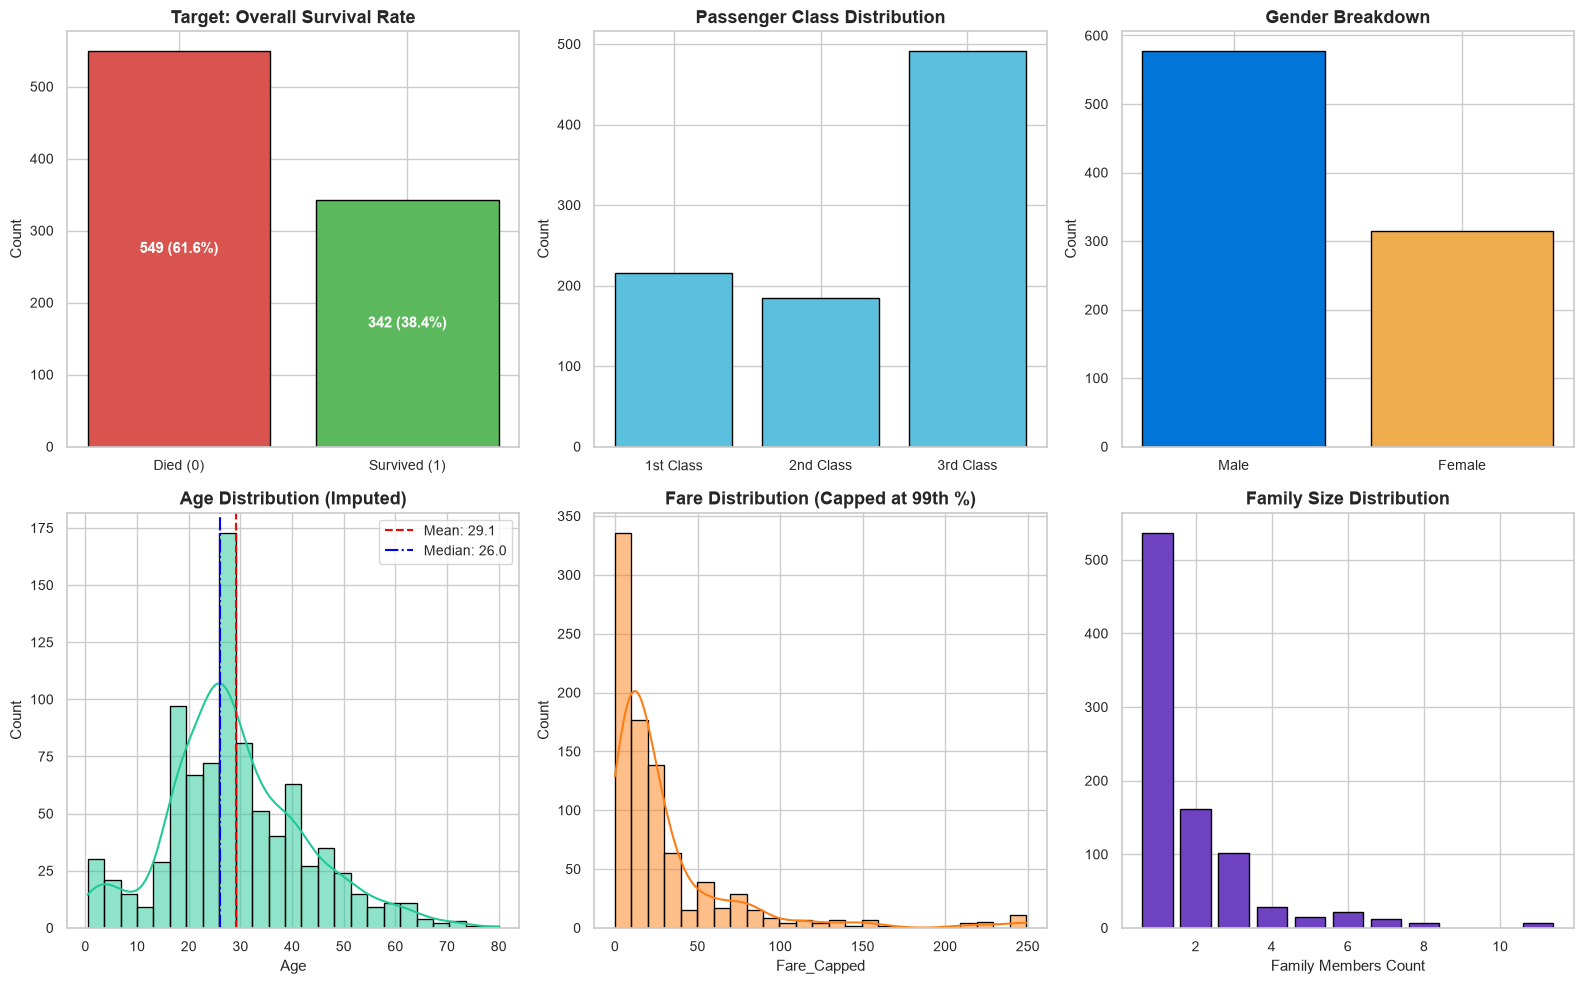

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Target: Survived
surv_vc = df_clean['Survived'].value_counts()
axes[0, 0].bar(['Died (0)', 'Survived (1)'], surv_vc.values, color=['#d9534f', '#5cb85c'], edgecolor='black')
axes[0, 0].set_title("Target: Overall Survival Rate", fontweight="bold")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(surv_vc.values):
    axes[0, 0].text(i, v/2, f"{v} ({v/len(df_clean)*100:.1f}%)", ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# 2. Pclass
pclass_vc = df_clean['Pclass'].value_counts().sort_index()
axes[0, 1].bar(['1st Class', '2nd Class', '3rd Class'], pclass_vc.values, color='#5bc0de', edgecolor='black')
axes[0, 1].set_title("Passenger Class Distribution", fontweight="bold")
axes[0, 1].set_ylabel("Count")

# 3. Sex
sex_vc = df_clean['Sex'].value_counts()
axes[0, 2].bar(sex_vc.index.str.capitalize(), sex_vc.values, color=['#0275d8', '#f0ad4e'], edgecolor='black')
axes[0, 2].set_title("Gender Breakdown", fontweight="bold")
axes[0, 2].set_ylabel("Count")

# 4. Age Distribution
sns.histplot(df_clean['Age'], kde=True, ax=axes[1, 0], color='#20c997', bins=25, edgecolor='black')
axes[1, 0].axvline(df_clean['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['Age'].mean():.1f}")
axes[1, 0].axvline(df_clean['Age'].median(), color='blue', linestyle='-.', label=f"Median: {df_clean['Age'].median():.1f}")
axes[1, 0].set_title("Age Distribution (Imputed)", fontweight="bold")
axes[1, 0].legend()

# 5. Capped Fare Distribution
sns.histplot(df_clean['Fare_Capped'], kde=True, ax=axes[1, 1], color='#fd7e14', bins=25, edgecolor='black')
axes[1, 1].set_title("Fare Distribution (Capped at 99th %)", fontweight="bold")

# 6. Family Size
fam_vc = df_clean['FamilySize'].value_counts().sort_index()
axes[1, 2].bar(fam_vc.index, fam_vc.values, color='#6f42c1', edgecolor='black')
axes[1, 2].set_title("Family Size Distribution", fontweight="bold")
axes[1, 2].set_xlabel("Family Members Count")

plt.tight_layout()
plt.show()

### 5.4 Bivariate Survival Drivers

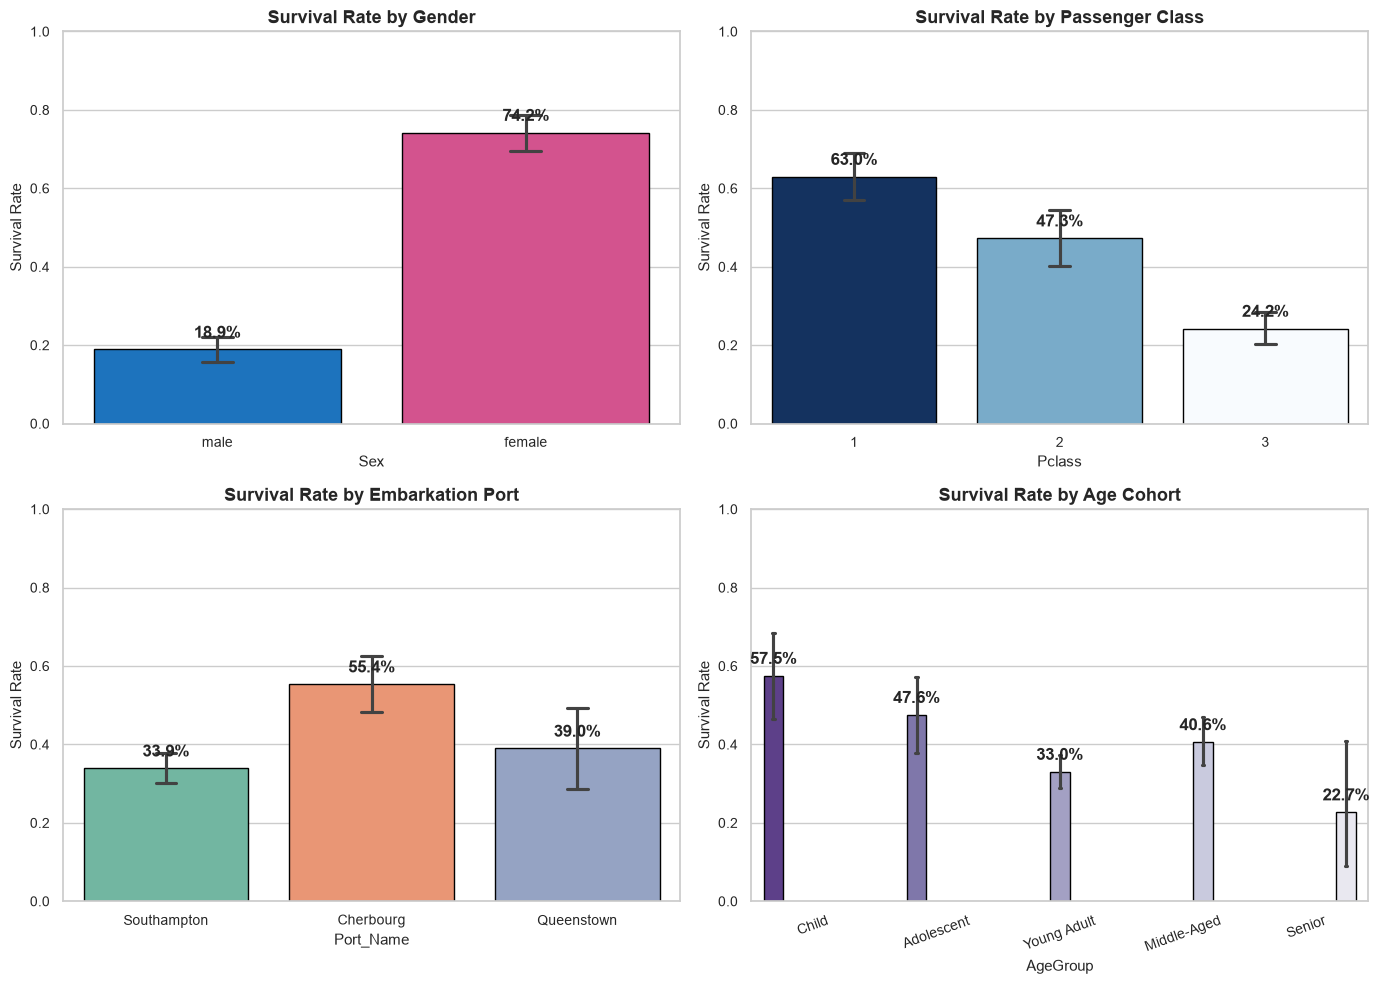

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival by Sex
sns.barplot(x="Sex", y="Survived", hue="Sex", legend=False, data=df_clean, ax=axes[0, 0], palette=["#0275d8", "#e83e8c"], capsize=0.1, edgecolor="black")
axes[0, 0].set_title("Survival Rate by Gender", fontweight="bold")
axes[0, 0].set_ylabel("Survival Rate")
axes[0, 0].set_ylim(0, 1.0)
for p in axes[0, 0].patches:
    h = p.get_height()
    axes[0, 0].text(p.get_x() + p.get_width() / 2, h + 0.03, f"{h*100:.1f}%", ha="center", fontweight="bold")

# 2. Survival by Pclass
sns.barplot(x="Pclass", y="Survived", hue="Pclass", legend=False, data=df_clean, ax=axes[0, 1], palette="Blues_r", capsize=0.1, edgecolor="black")
axes[0, 1].set_title("Survival Rate by Passenger Class", fontweight="bold")
axes[0, 1].set_ylabel("Survival Rate")
axes[0, 1].set_ylim(0, 1.0)
for p in axes[0, 1].patches:
    h = p.get_height()
    axes[0, 1].text(p.get_x() + p.get_width() / 2, h + 0.03, f"{h*100:.1f}%", ha="center", fontweight="bold")

# 3. Survival by Embarkation Port
port_map = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
df_clean["Port_Name"] = df_clean["Embarked"].map(port_map)
sns.barplot(x="Port_Name", y="Survived", hue="Port_Name", legend=False, data=df_clean, ax=axes[1, 0], palette="Set2", capsize=0.1, edgecolor="black")
axes[1, 0].set_title("Survival Rate by Embarkation Port", fontweight="bold")
axes[1, 0].set_ylabel("Survival Rate")
axes[1, 0].set_ylim(0, 1.0)
for p in axes[1, 0].patches:
    h = p.get_height()
    axes[1, 0].text(p.get_x() + p.get_width() / 2, h + 0.03, f"{h*100:.1f}%", ha="center", fontweight="bold")

# 4. Survival by Age Group
sns.barplot(x="AgeGroup", y="Survived", hue="AgeGroup", legend=False, data=df_clean, ax=axes[1, 1], palette="Purples_r", capsize=0.1, edgecolor="black")
axes[1, 1].set_title("Survival Rate by Age Cohort", fontweight="bold")
axes[1, 1].set_ylabel("Survival Rate")
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].tick_params(axis="x", rotation=20)
for p in axes[1, 1].patches:
    h = p.get_height()
    axes[1, 1].text(p.get_x() + p.get_width() / 2, h + 0.03, f"{h*100:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### 5.5 Correlation Matrix

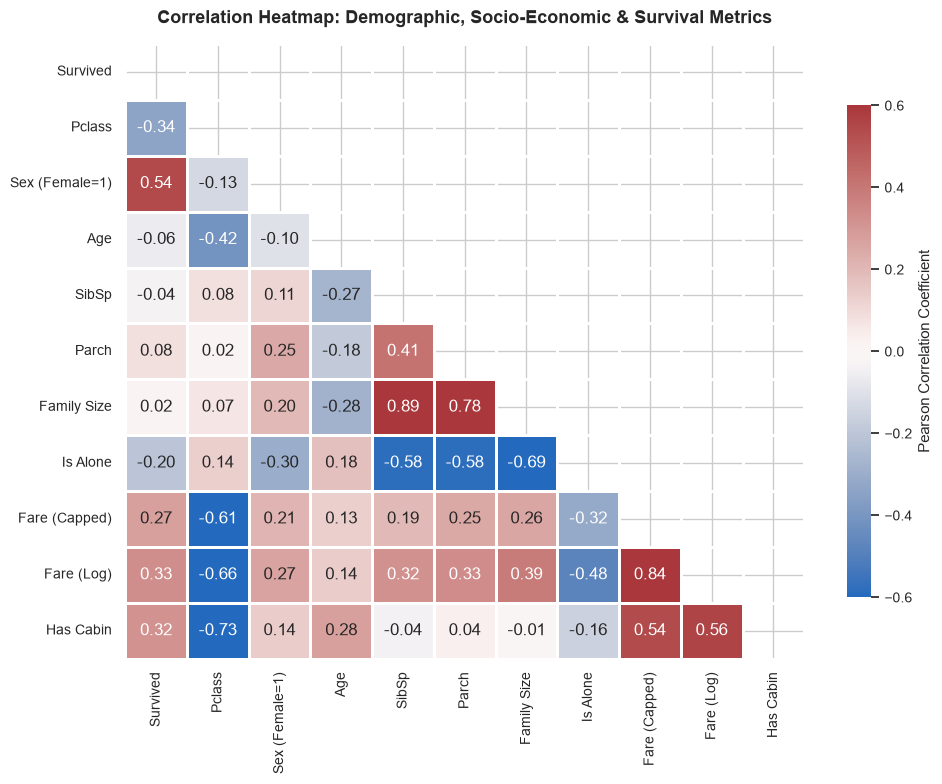

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_df = df_clean.copy()
corr_df["Sex_Female"] = (corr_df["Sex"] == "female").astype(int)

cols = ["Survived", "Pclass", "Sex_Female", "Age", "SibSp", "Parch", "FamilySize", "IsAlone", "Fare_Capped", "Fare_Log", "Has_Cabin"]
labels = ["Survived", "Pclass", "Sex (Female=1)", "Age", "SibSp", "Parch", "Family Size", "Is Alone", "Fare (Capped)", "Fare (Log)", "Has Cabin"]

corr_matrix = corr_df[cols].corr()
corr_matrix.columns = labels
corr_matrix.index = labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-0.6, vmax=0.6,
            linewidths=1.0, linecolor="white", cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"}, ax=ax)

ax.set_title("Correlation Heatmap: Demographic, Socio-Economic & Survival Metrics", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### 5.6 Multivariate Interactions & Behavioral Subsets

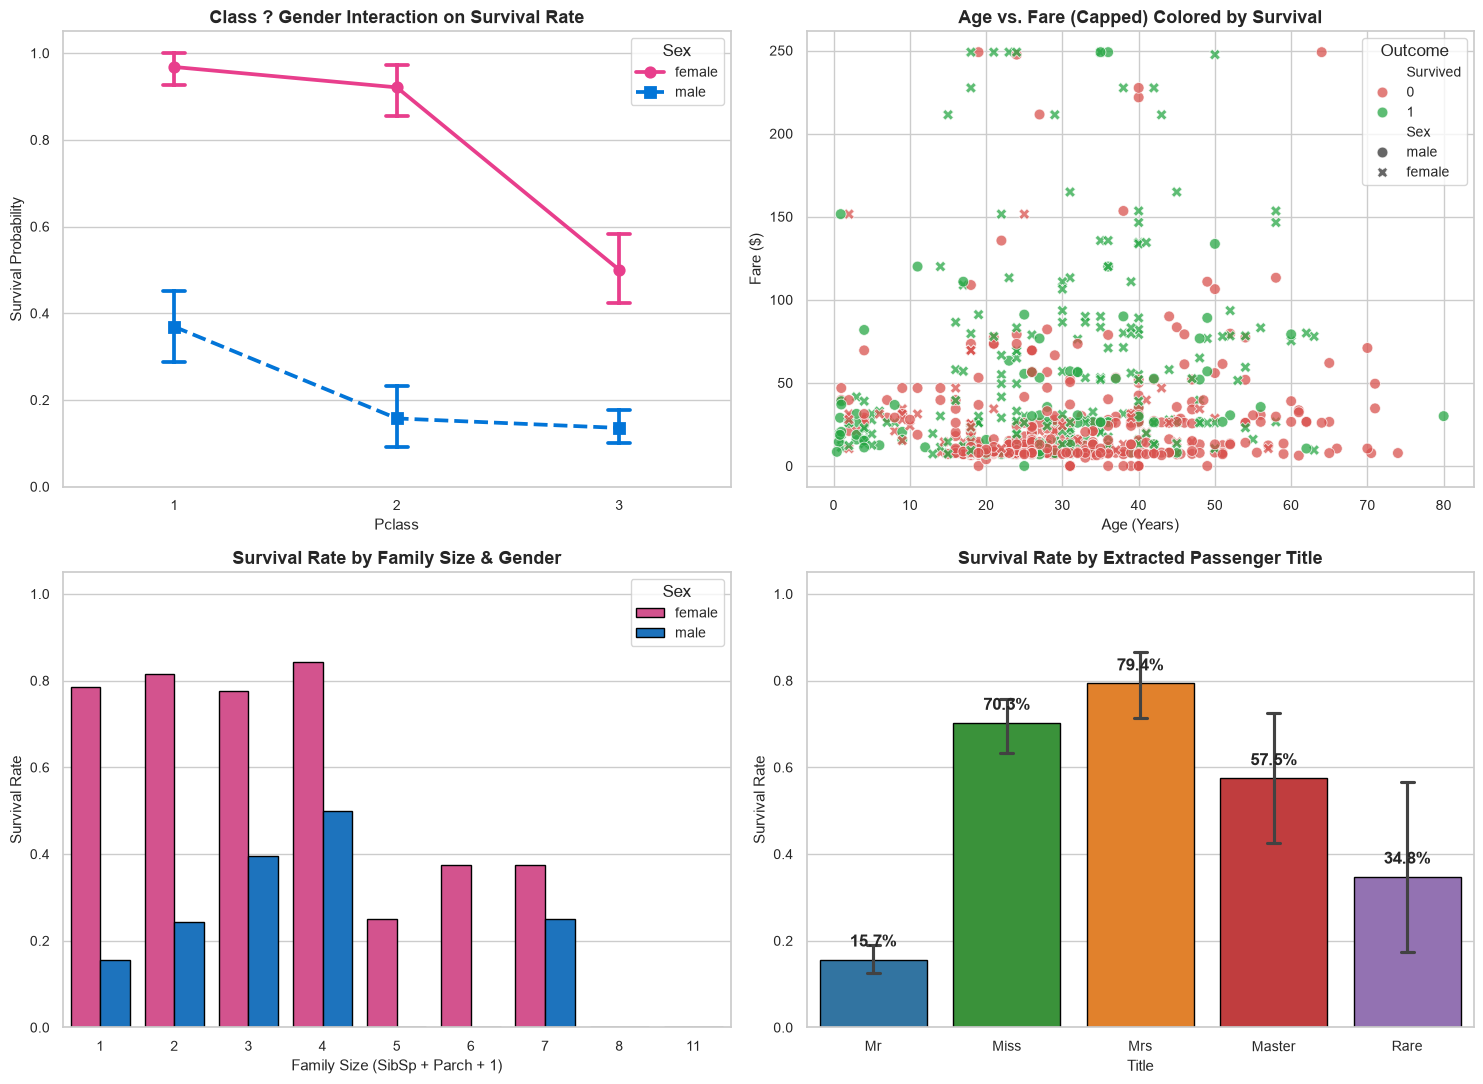

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Pclass x Sex Interaction
sns.pointplot(x="Pclass", y="Survived", hue="Sex", data=df_clean, ax=axes[0, 0], palette={"male": "#0275d8", "female": "#e83e8c"}, markers=["o", "s"], linestyles=["-", "--"], capsize=0.1)
axes[0, 0].set_title("Class ? Gender Interaction on Survival Rate", fontweight="bold")
axes[0, 0].set_ylabel("Survival Probability")
axes[0, 0].set_ylim(0, 1.05)

# 2. Fare vs Age by Survival
sns.scatterplot(x="Age", y="Fare_Capped", hue="Survived", style="Sex", data=df_clean, ax=axes[0, 1], palette={0: "#d9534f", 1: "#28a745"}, alpha=0.75, s=60)
axes[0, 1].set_title("Age vs. Fare (Capped) Colored by Survival", fontweight="bold")
axes[0, 1].set_xlabel("Age (Years)")
axes[0, 1].set_ylabel("Fare ($)")
axes[0, 1].legend(title="Outcome", loc="upper right")

# 3. Family Size and Sex
sns.barplot(x="FamilySize", y="Survived", hue="Sex", data=df_clean, ax=axes[1, 0], palette={"male": "#0275d8", "female": "#e83e8c"}, errorbar=None, edgecolor="black")
axes[1, 0].set_title("Survival Rate by Family Size & Gender", fontweight="bold")
axes[1, 0].set_xlabel("Family Size (SibSp + Parch + 1)")
axes[1, 0].set_ylabel("Survival Rate")
axes[1, 0].set_ylim(0, 1.05)

# 4. Title breakdown
top_titles = ["Mr", "Miss", "Mrs", "Master", "Rare"]
sns.barplot(x="Title", y="Survived", hue="Title", legend=False, data=df_clean[df_clean["Title"].isin(top_titles)], ax=axes[1, 1], palette="tab10", order=top_titles, capsize=0.1, edgecolor="black")
axes[1, 1].set_title("Survival Rate by Extracted Passenger Title", fontweight="bold")
axes[1, 1].set_ylabel("Survival Rate")
axes[1, 1].set_ylim(0, 1.05)
for p in axes[1, 1].patches:
    h = p.get_height()
    axes[1, 1].text(p.get_x() + p.get_width() / 2, h + 0.03, f"{h*100:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Key Findings and Analytical Conclusions

### 1. Gender Disparity ("Women and Children First")
- **Female survival rate was 74.20%**, compared to only **18.89% for males** (a $4\times$ differential).
- Gender is the single strongest univariate predictor of survival ($r = +0.54$).

### 2. Socio-Economic Class Hierarchy
- 1st Class passengers exhibited a **62.96% survival rate**, 2nd Class **47.28%**, and 3rd Class **24.24%**.
- 1st and 2nd class females enjoyed $>92\%$ survival probability, whereas 3rd class males had a dismal $13.5\%$ survival rate.

### 3. Family Dynamics & Traveling Party Size
- Traveling completely alone (`IsAlone = 1`, 60.3% of passengers) yielded an inferior survival rate ($30.35\%$).
- Moderate family sizes of 2 to 4 members peaked at **$55\% - 72\%$ survival**, reflecting coordinated evacuation assistance. Large families ($\ge 5$) experienced severe survival drops ($<20\%$).

### 4. Cabin Allocation & Location
- Passengers with recorded cabin locations (`Has_Cabin = 1`) had a **66.67% survival rate**, compared to **29.99%** for those without recorded cabins, strongly tied to upper-deck proximity.

### 5. Preprocessing Effectiveness
- Title-based grouped median imputation prevented age distribution distortion while retaining true variance.
- Outlier Winsorization at the 99th percentile and log-transformation successfully suppressed extreme leverage in `Fare` while preserving socio-economic contrast.